In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("🚀 Iniciando Preprocesamiento Avanzado para YOLO (51 puntos)...")

# ⚠️ Asegúrate de que esta ruta sigue siendo tu ruta correcta
ruta_base = r"C:\Users\Anxo\Desktop\Proyecto final 4\archive (3)\Squat_Data\Squat_Data"
X, y, secuencia_temporal = [], [], []

for root, dirs, files in os.walk(ruta_base):
    archivos_ordenados = sorted([f for f in files if f.endswith(".npy")])
    
    for archivo in archivos_ordenados:
        ruta_archivo = os.path.join(root, archivo)
        try:
            res = np.load(ruta_archivo)
            if res.shape == (132,):
                # 1. EXTRACCIÓN Y ADAPTACIÓN A YOLO (51 valores)
                indices_yolo = [0, 2, 5, 7, 8, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]
                puntos_51 = []
                for idx in indices_yolo:
                    puntos_51.extend(res[idx*4 : idx*4+3])
                
                puntos_51 = np.array(puntos_51)
                
                # 2. NORMALIZACIÓN BIOMECÁNICA (Centrar cadera en 0,0)
                hip_l = puntos_51[11*3 : 11*3+3]
                hip_r = puntos_51[12*3 : 12*3+3]
                centro_cadera = (hip_l + hip_r) / 2
                
                res_norm = puntos_51.copy()
                for i in range(17):
                    res_norm[i*3 : i*3+3] -= centro_cadera
                
                secuencia_temporal.append(res_norm)
            
            if len(secuencia_temporal) == 30:
                X.append(secuencia_temporal)
                y.append(1 if "Valid" in root else 0)
                
                # 3. DATA AUGMENTATION (Efecto Espejo)
                secuencia_espejo = np.array(secuencia_temporal).copy()
                secuencia_espejo[:, 0::3] *= -1  
                
                X.append(secuencia_espejo)
                y.append(1 if "Valid" in root else 0)
                
                secuencia_temporal = [] 
        except:
            continue

# 4. PREPARACIÓN FINAL
X = np.array(X)
y = to_categorical(y).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Preprocesamiento completado con éxito.")
print(f"📊 Forma de X_train (Debería ser N, 30, 51): {X_train.shape}")

🚀 Iniciando Preprocesamiento Avanzado para YOLO (51 puntos)...
✅ Preprocesamiento completado con éxito.
📊 Forma de X_train (Debería ser N, 30, 51): (1144, 30, 51)


In [22]:
print("🧠 Construyendo la Red Neuronal (LSTM)...")

model_ia = keras.Sequential([
    # Capa de entrada sincronizada con YOLO
    layers.Input(shape=(30, 51)),
    
    layers.LSTM(64, return_sequences=True, activation='tanh'),
    layers.Dropout(0.2),
    
    layers.LSTM(128, return_sequences=True, activation='tanh'),
    layers.Dropout(0.2),
    
    layers.LSTM(64, return_sequences=False, activation='tanh'),
    layers.Dropout(0.2),
    
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    
    # Capa de salida: NULA (0) o VÁLIDA (1)
    layers.Dense(2, activation='softmax')
])

model_ia.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model_ia.summary()

🧠 Construyendo la Red Neuronal (LSTM)...


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 30, 64)         │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,226 (719.63 KB)

 Trainable params: 184,226 (719.63 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
print("🏋️‍♂️ Iniciando el entrenamiento del modelo...")

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_categorical_accuracy', 
    patience=20, 
    restore_best_weights=True
)

# GUARDAMOS EL MODELO CON ESTE NOMBRE DEFINITIVO
model_checkpoint = keras.callbacks.ModelCheckpoint(
    'modelo_squat_biomecanico.h5', 
    monitor='val_categorical_accuracy',
    save_best_only=True
)

history = model_ia.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint]
)

print("🏆 ¡Modelo guardado correctamente como 'modelo_squat_biomecanico.h5'!")

🏋️‍♂️ Iniciando el entrenamiento del modelo...
Epoch 1/150
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - categorical_accuracy: 0.4608 - loss: 0.6978

36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - categorical_accuracy: 0.4913 - loss: 0.6963 - val_categorical_accuracy: 0.5420 - val_loss: 0.6897
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.5175 - loss: 0.6927 - val_categorical_accuracy: 0.5280 - val_loss: 0.6885
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - categorical_accuracy: 0.5594 - loss: 0.6860 - val_categorical_accuracy: 0.5175 - val_loss: 0.6909
Epoch 4/150
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - categorical_accuracy: 0.5660 - loss: 0.6808

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.5813 - loss: 0.6718 - val_categorical_accuracy: 0.5629 - val_loss: 0.6722
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - categorical_accuracy: 0.6032 - loss: 0.6710

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.5883 - loss: 0.6721 - val_categorical_accuracy: 0.6329 - val_loss: 0.6484
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.6058 - loss: 0.6357 - val_categorical_accuracy: 0.6224 - val_loss: 0.6076
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.6469 - loss: 0.5978 - val_categorical_accuracy: 0.5664 - val_loss: 0.7400
Epoch 8/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.6600 - loss: 0.6035 - val_categorical_accuracy: 0.6329 - val_loss: 0.6283
Epoch 9/150
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - categorical_accuracy: 0.6864 - loss: 0.5626

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.6888 - loss: 0.5540 - val_categorical_accuracy: 0.6399 - val_loss: 0.6018
Epoch 10/150
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - categorical_accuracy: 0.7118 - loss: 0.5592

...

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.9388 - loss: 0.1401 - val_categorical_accuracy: 0.9056 - val_loss: 0.2066
Epoch 56/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.9371 - loss: 0.1328 - val_categorical_accuracy: 0.8986 - val_loss: 0.2246
Epoch 57/150
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - categorical_accuracy: 0.9327 - loss: 0.1669

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.9327 - loss: 0.1592 - val_categorical_accuracy: 0.9091 - val_loss: 0.2246
Epoch 58/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.9449 - loss: 0.1368 - val_categorical_accuracy: 0.9021 - val_loss: 0.2508
Epoch 59/150
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - categorical_accuracy: 0.9224 - loss: 0.1637

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - categorical_accuracy: 0.9187 - loss: 0.1565 - val_categorical_accuracy: 0.9231 - val_loss: 0.1788
Epoch 60/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.9580 - loss: 0.0971 - val_categorical_accuracy: 0.9161 - val_loss: 0.1908
Epoch 61/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.9563 - loss: 0.0979 - val_categorical_accuracy: 0.8741 - val_loss: 0.4416
Epoch 62/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.9371 - loss: 0.1503 - val_categorical_accuracy: 0.8671 - val_loss: 0.3161
Epoch 63/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.9266 - loss: 0.1539 - val_categorical_accuracy: 0.8986 - val_loss: 0.2553
Epoch 64/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.9432 - loss: 0.1433 - val_categorical_accuracy: 0.9161 - val_loss: 0.2257
Epoch 65/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.9537 - loss: 0.1

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.9563 - loss: 0.1196 - val_categorical_accuracy: 0.9371 - val_loss: 0.1798
Epoch 72/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.9528 - loss: 0.1130 - val_categorical_accuracy: 0.9126 - val_loss: 0.2016
Epoch 73/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.9668 - loss: 0.0892 - val_categorical_accuracy: 0.9091 - val_loss: 0.2586
Epoch 74/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.9537 - loss: 0.1143 - val_categorical_accuracy: 0.9266 - val_loss: 0.2507
Epoch 75/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.9554 - loss: 0.1419 - val_categorical_accuracy: 0.9091 - val_loss: 0.2386
Epoch 76/150
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - categorical_accuracy: 0.9673 - loss: 0.0827

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.9659 - loss: 0.0822 - val_categorical_accuracy: 0.9476 - val_loss: 0.1671
Epoch 77/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.9633 - loss: 0.0958 - val_categorical_accuracy: 0.9371 - val_loss: 0.1853
Epoch 78/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.9677 - loss: 0.0800 - val_categorical_accuracy: 0.9126 - val_loss: 0.2716
Epoch 79/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.9677 - loss: 0.0821 - val_categorical_accuracy: 0.9161 - val_loss: 0.2631
Epoch 80/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.9659 - loss: 0.0873 - val_categorical_accuracy: 0.9266 - val_loss: 0.2188
Epoch 81/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.9720 - loss: 0.0666 - val_categorical_accuracy: 0.9301 - val_loss: 0.2134
Epoch 82/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.9720 - loss: 0.0

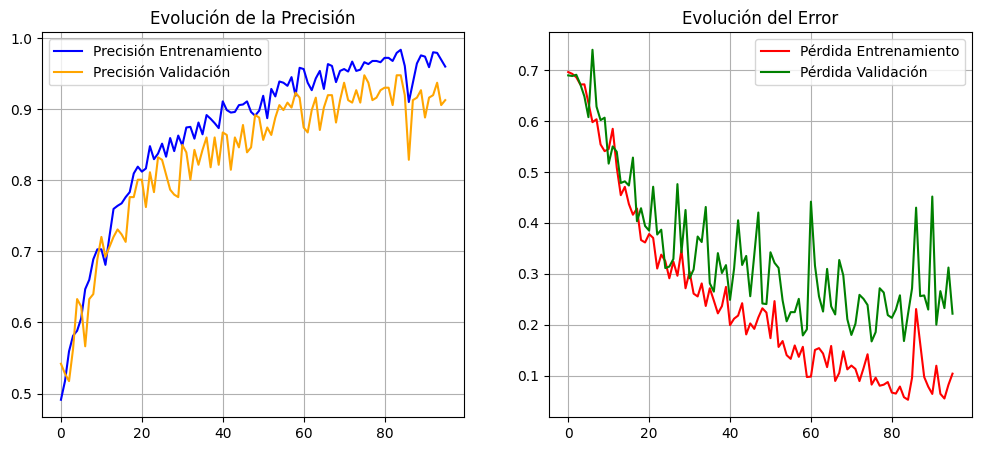

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - categorical_accuracy: 0.9476 - loss: 0.1671
🎯 Precisión final demostrada: 94.76%


In [24]:
# Gráfica de Precisión
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['categorical_accuracy'], label='Precisión Entrenamiento', color='blue')
plt.plot(history.history['val_categorical_accuracy'], label='Precisión Validación', color='orange')
plt.title('Evolución de la Precisión')
plt.legend()
plt.grid(True)

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento', color='red')
plt.plot(history.history['val_loss'], label='Pérdida Validación', color='green')
plt.title('Evolución del Error')
plt.legend()
plt.grid(True)
plt.show()

# Resultado en el Test
res_test = model_ia.evaluate(X_test, y_test)
print(f"🎯 Precisión final demostrada: {round(res_test[1] * 100, 2)}%")

In [1]:
import cv2
import numpy as np
from ultralytics import YOLO
from tensorflow.keras.models import load_model

print("🎥 Iniciando el Juez Virtual (YOLOv8 + LSTM)...")

# Cargamos los dos cerebros
yolo_pose = YOLO('yolov8n-pose.pt')
modelo_juez = load_model('modelo_squat_biomecanico.h5')

# ⚠️ PON AQUÍ LA RUTA DE UN VÍDEO TUYO (GRABADO DE PERFIL, NO DE ESPALDAS)
video_path = r"AQUI_TU_RUTA_AL_VIDEO.mp4" 
cap = cv2.VideoCapture((r"C:\Users\Anxo\Downloads\455kg squat FIGHT Jesus Olivares.mp4"))

secuencia = []
prediccion_actual = "ESPERANDO..."
color_texto = (255, 255, 255)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    
    frame_res = cv2.resize(frame, (800, 600))
    results = yolo_pose.predict(frame_res, conf=0.5, verbose=False)
    
    if results[0].keypoints and len(results[0].keypoints.data) > 0:
        kp = results[0].keypoints.data[0].cpu().numpy().flatten()
        
        # Si YOLO detecta el esqueleto entero (51 valores)
        if len(kp) == 51:
            
            # --- EL PARCHE BIOMECÁNICO EN TIEMPO REAL ---
            hip_l = kp[11*3 : 11*3+3]
            hip_r = kp[12*3 : 12*3+3]
            centro_cadera = (hip_l + hip_r) / 2
            
            kp_norm = kp.copy()
            for i in range(17):
                kp_norm[i*3 : i*3+3] -= centro_cadera
            # --------------------------------------------
            
            secuencia.append(kp_norm)
            if len(secuencia) > 30: 
                secuencia.pop(0)
            
            # Cuando tenemos 30 fotogramas guardados, la IA decide
            if len(secuencia) == 30:
                input_data = np.expand_dims(secuencia, axis=0)
                pred = modelo_juez.predict(input_data, verbose=0)[0]
                
                # pred[0] = probabilidad de NULA | pred[1] = probabilidad de VALIDA
                if pred[1] > pred[0]:
                    prediccion_actual = f"VALIDA ({(pred[1]*100):.1f}%)"
                    color_texto = (0, 255, 0) # Verde
                else:
                    prediccion_actual = f"NULA ({(pred[0]*100):.1f}%)"
                    color_texto = (0, 0, 255) # Rojo
                    
        # Dibujamos el esqueleto y la decisión
        frame_res = results[0].plot()
        cv2.putText(frame_res, prediccion_actual, (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color_texto, 4)
        
    cv2.imshow("Squat AI Juez", frame_res)
    
    # Pulsa 'q' para salir de la ventana de vídeo
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

🎥 Iniciando el Juez Virtual (YOLOv8 + LSTM)...


In [ ]:
import os
import numpy as np
import cv2
import random
from tensorflow.keras.models import load_model

# 1. CARGA DEL MODELO (Asegúrate de tener el archivo .h5 en la misma carpeta)
try:
    model_ia = load_model('modelo_squat_yolo.h5')
    print("✅ Modelo IA cargado correctamente.")
except:
    print("❌ Error: No se encuentra 'modelo_squat_yolo.h5'. Ejecuta primero la celda de entrenamiento.")
    raise

# 2. RUTA RAÍZ (Ajusta si es necesario)
ruta_raiz = r"C:\Users\Anxo\Desktop\Proyecto final 4\archive (3)\Squat_Data\Squat_Data"

# 3. CONEXIONES DE MEDIAPIPE (Stickman)
# Definimos qué puntos se conectan entre sí para formar el esqueleto
CONEXIONES_STICKMAN = [
    # Torso y Cabeza (Rojo)
    ((11, 12), (255, 0, 0)), ((11, 23), (255, 0, 0)), ((12, 24), (255, 0, 0)), ((23, 24), (255, 0, 0)),
    ((8, 6), (255, 0, 0)), ((6, 5), (255, 0, 0)), ((5, 4), (255, 0, 0)), ((4, 0), (255, 0, 0)),
    ((0, 1), (255, 0, 0)), ((1, 2), (255, 0, 0)), ((2, 3), (255, 0, 0)), ((3, 7), (255, 0, 0)),
    # Brazos (Verde)
    ((11, 13), (0, 255, 0)), ((13, 15), (0, 255, 0)), ((15, 17), (0, 255, 0)), ((15, 19), (0, 255, 0)), ((15, 21), (0, 255, 0)),
    ((12, 14), (0, 255, 0)), ((14, 16), (0, 255, 0)), ((16, 18), (0, 255, 0)), ((16, 20), (0, 255, 0)), ((16, 22), (0, 255, 0)),
    # Piernas (Azul)
    ((23, 25), (0, 0, 255)), ((25, 27), (0, 0, 255)), ((27, 29), (0, 0, 255)), ((27, 31), (0, 0, 255)),
    ((24, 26), (0, 0, 255)), ((26, 28), (0, 0, 255)), ((28, 30), (0, 0, 255)), ((28, 32), (0, 0, 255))
]

def dibujar_stickman(puntos_132):
    """ Dibuja el stickman articulado en un lienzo negro """
    lienzo = np.zeros((600, 800, 3), dtype=np.uint8)
    puntos_codificados = []
    
    # 1. Extraer y escalar puntos
    for i in range(33):
        x = int(puntos_132[i*4] * 800)
        y = int(puntos_132[i*4 + 1] * 600)
        puntos_codificados.append((x, y))
        # Dibujar punto
        if 0 <= x < 800 and 0 <= y < 600:
            cv2.circle(lienzo, (x, y), 3, (255, 255, 255), -1)

    # 2. Dibujar líneas de conexión
    for conexion, color in CONEXIONES_STICKMAN:
        p1_idx, p2_idx = conexion
        p1 = puntos_codificados[p1_idx]
        p2 = puntos_codificados[p2_idx]
        
        # Validar que los puntos estén dentro del lienzo
        if (0 <= p1[0] < 800 and 0 <= p1[1] < 600) and \
           (0 <= p2[0] < 800 and 0 <= p2[1] < 600):
            cv2.line(lienzo, p1, p2, color, 2)
            
    return lienzo

def jugar_ronda_visual():
    """ Ejecuta una ronda del minijuego """
    # Elección aleatoria de clase y carpeta
    clase_real = random.choice([0, 1])
    nombre_clase = "Valid" if clase_real == 1 else "Invalid"
    ruta_clase = os.path.join(ruta_raiz, nombre_clase)
    
    carpetas = [d for d in os.listdir(ruta_clase) if os.path.isdir(os.path.join(ruta_clase, d))]
    video_id = random.choice(carpetas)
    ruta_video = os.path.join(ruta_clase, video_id)
    archivos = sorted([f for f in os.listdir(ruta_video) if f.endswith('.npy')])
    
    if len(archivos) < 30: return jugar_ronda_visual() # Reintentar si es corto

    secuencia_ia = []
    indices_yolo = [0, 2, 5, 7, 8, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]
    
    # --- REPRODUCCIÓN DEL STICKMAN ---
    print(f"🎬 Analizando movimiento en: {nombre_clase}/{video_id}...")
    for i in range(min(len(archivos), 70)): # Mostramos hasta 70 frames para ver todo el rango
        data = np.load(os.path.join(ruta_video, archivos[i]))
        
        # Generar stickman coloreado
        img_stickman = dibujar_stickman(data)
        cv2.putText(img_stickman, "OBSERVA LA PROFUNDIDAD", (150, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        cv2.imshow('Minijuego: Stickman Squat Judge', img_stickman)
        cv2.waitKey(40) # Velocidad de reproducción (40ms = 25fps aprox)
        
        # Guardamos secuencia para la IA (solo los primeros 30 frames)
        if i < 30:
            puntos_51 = []
            for idx in indices_yolo:
                puntos_51.extend(data[idx*4 : idx*4+3])
            secuencia_ia.append(puntos_51)

    # --- FASE DE VOTACIÓN ---
    print("\n❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?")
    voto = None
    while voto not in ['v', 'n']:
        tecla = cv2.waitKey(0) & 0xFF
        if tecla == ord('v'): voto = 'v'
        elif tecla == ord('n'): voto = 'n'
    
    voto_num = 1 if voto == 'v' else 0
    
    # Predicción IA
    pred = model_ia.predict(np.expand_dims(secuencia_ia, axis=0), verbose=0)[0]
    ia_decide = np.argmax(pred)
    ia_conf = pred[ia_decide] * 100
    
    # --- PANTALLA DE RESULTADOS ---
    resultado_img = np.zeros((600, 800, 3), dtype=np.uint8)
    color_voto = (0, 255, 0) if voto_num == clase_real else (0, 0, 255)
    color_ia = (0, 255, 0) if ia_decide == clase_real else (0, 0, 255)
    
    cv2.putText(resultado_img, f"TU VOTO: {voto.upper()}", (100, 150), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255,255,255), 3)
    cv2.putText(resultado_img, f"REAL DE LA DB: {nombre_clase.upper()}", (100, 250), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color_voto, 3)
    cv2.putText(resultado_img, f"IA DICE: {'VALIDA' if ia_decide == 1 else 'NULA'}", (100, 380), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (200,200,200), 2)
    cv2.putText(resultado_img, f"Confianza IA: {ia_conf:.1f}%", (100, 430), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (150,150,150), 1)
    
    # Mensaje final
    msj_final = "¡COINCIDES CON LA DB!" if voto_num == clase_real else "¡LA DB DICE LO CONTRARIO!"
    cv2.putText(resultado_img, msj_final, (100, 520), cv2.FONT_HERSHEY_SIMPLEX, 1, color_voto, 2)
    cv2.putText(resultado_img, "Pulsa cualquier tecla para otra ronda ('q' para salir)", (120, 570), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)
    
    cv2.imshow('Minijuego: Stickman Squat Judge', resultado_img)
    
    # Esperar tecla para continuar o salir
    final_tecla = cv2.waitKey(0) & 0xFF
    if final_tecla == ord('q'):
        return False
    return True

# --- BUCLE PRINCIPAL DEL JUEGO ---
print("🎮 BIENVENIDO AL JUEGO 'STICKMAN SQUAT JUDGE'")
print("Instrucciones: Mira el movimiento del muñeco articulado.")
print("Cuando se detenga, pulsa 'v' para Válida o 'n' para Nula.")
print("Pulsa 'q' en la pantalla de resultados para salir.")

try:
    jugando = True
    while jugando:
        jugando = jugar_ronda_visual()
except KeyboardInterrupt:
    print("\nJuego interrumpido por el usuario.")
finally:
    cv2.destroyAllWindows()
    print("👋 ¡Gracias por jugar! El juez de hierro se despide.")

✅ Modelo IA cargado correctamente.
🎮 BIENVENIDO AL JUEGO 'STICKMAN SQUAT JUDGE'
Instrucciones: Mira el movimiento del muñeco articulado.
Cuando se detenga, pulsa 'v' para Válida o 'n' para Nula.
Pulsa 'q' en la pantalla de resultados para salir.
🎬 Analizando movimiento en: Valid/55...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/112...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/79...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/3...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/55...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/35...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/22...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/98...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
👋 ¡Gracias por jugar! El juez de hierro se despide.


In [27]:
import cv2
from ultralytics import YOLO
import numpy as np
from tensorflow.keras.models import load_model
import time

# 1. CARGA DE MODELOS
model_ia = load_model('modelo_squat_yolo.h5')
yolo_pose = YOLO('yolov8n-pose.pt')

# 2. VÍDEO (Cambia a 0 para Webcam)
cap = cv2.VideoCapture(r"C:\Users\Anxo\Downloads\455kg squat FIGHT Jesus Olivares.mp4")

# 3. VARIABLES DE CONTROL Y BIOMECÁNICA
secuencia = []
contador_reps = 0
estado = "ESPERANDO"
mejor_confianza_valida = 0
y_hombros_inicial = None
max_inclinacion = 0
consejo_coach = "SISTEMA LISTO. ESPERANDO DESCENSO..."
luces_color = (100, 100, 100)

def calcular_angulo_torso(puntos):
    """Calcula la inclinación del torso respecto a la vertical"""
    # Hombro (5 o 6) y Cadera (11 o 12)
    hombro = puntos[5]
    cadera = puntos[11]
    
    dy = cadera[1] - hombro[1]
    dx = cadera[0] - hombro[0]
    
    # Ángulo en grados
    angulo = np.abs(np.degrees(np.arctan2(dx, dy)))
    return angulo

print("🚀 Coach Inteligente Activado...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    
    frame = cv2.resize(frame, (800, 600))
    results = yolo_pose.predict(frame, conf=0.3, verbose=False)
    
    if results[0].keypoints and len(results[0].keypoints.data) > 0:
        kp_data = results[0].keypoints.data[0].cpu().numpy()
        hombro_y = (kp_data[5][1] + kp_data[6][1]) / 2
        
        if y_hombros_inicial is None:
            y_hombros_inicial = hombro_y
            continue

        # Guardar secuencia para la IA
        kp_flat = kp_data.flatten()
        if len(kp_flat) == 51:
            secuencia.append(kp_flat)
        if len(secuencia) > 30: secuencia.pop(0)

        # --- LÓGICA DE COACHING ---
        distancia_bajada = hombro_y - y_hombros_inicial
        angulo_actual = calcular_angulo_torso(kp_data)

        if distancia_bajada > 40 and estado == "ESPERANDO":
            estado = "BAJANDO"
            mejor_confianza_valida = 0
            max_inclinacion = 0
            consejo_coach = "BAJANDO... MANTEN EL PECHO ALTO"
            luces_color = (100, 100, 100)

        if estado == "BAJANDO":
            # Registrar la peor inclinación durante la bajada
            if angulo_actual > max_inclinacion:
                max_inclinacion = angulo_actual
            
            if len(secuencia) == 30:
                res = model_ia.predict(np.expand_dims(secuencia, axis=0), verbose=0)[0]
                if res[1] > mejor_confianza_valida:
                    mejor_confianza_valida = res[1]

        # Al subir y terminar la rep
        if distancia_bajada < 30 and estado == "BAJANDO":
            # Veredicto de profundidad (IA)
            if mejor_confianza_valida > 0.70:
                contador_reps += 1
                luces_color = (255, 255, 255)
                # Feedback de técnica
                if max_inclinacion > 35:
                    consejo_coach = f"VALIDA. Cuidado: Torso inclinado ({int(max_inclinacion)}°). Fortalece Lumbar."
                else:
                    consejo_coach = "¡PERFECTA! Buena verticalidad y profundidad."
            else:
                luces_color = (0, 0, 255)
                consejo_coach = "NULA. Falta profundidad. Mejora movilidad de tobillo."
            
            estado = "ESPERANDO"

    # --- RENDERIZADO DEL COACH HUD ---
    frame_final = results[0].plot()
    
    # Caja de consejos inferior
    cv2.rectangle(frame_final, (0, 530), (800, 600), (0, 0, 0), -1)
    cv2.putText(frame_final, consejo_coach, (20, 570), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    
    # Luces de Juez
    for i in range(3):
        cv2.circle(frame_final, (650 + (i*45), 45), 18, luces_color, -1)
        cv2.circle(frame_final, (650 + (i*45), 45), 18, (255, 255, 255), 1)

    # Marcador superior
    cv2.rectangle(frame_final, (0, 0), (200, 60), (0, 0, 0), -1)
    cv2.putText(frame_final, f"REPS: {contador_reps}", (20, 45), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

    cv2.imshow('AI SQUAT COACH - Jesus Olivares Edition', frame_final)
    if cv2.waitKey(1) & 0xFF == ord('q'): break

cap.release()
cv2.destroyAllWindows()

🚀 Coach Inteligente Activado...
